<a href="https://colab.research.google.com/github/Dwiynt/Beginer_python/blob/main/Cloudmask_Sentinel2_PKU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import ee
import geemap
import xarray as xr
!pip install xee
import xee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 61.3 MB/s eta 0:00:00


In [2]:
ee.Authenticate()
ee.Initialize(
    project = 'ee-dwiyanto',
    opt_url = 'https://earthengine-highvolume.googleapis.com'
)

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_7TDKVSyKvBdmMqW?ref=4i2o6


In [3]:
map = geemap.Map(basemap = 'SATELLITE')
map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

In [5]:
roi = map.draw_last_feature.geometry()

AttributeError: type object 'map' has no attribute 'draw_last_feature'

In [4]:
roi

NameError: name 'roi' is not defined

In [24]:
def cloud_mask(img):
  qa = img.select('probability')
  cloud_mask = qa.lt(20)
  ms = img.select('B.*').multiply(0.0001)
  ndvi = ms.normalizedDifference(['B8', 'B4']).rename('ndvi')
  return ndvi.updateMask(cloud_mask).copyProperties(img, ['system:time_start'])

sen2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").linkCollection(
        ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY"), 'probability'
    )
    .filterDate('2024','2025')
    .filterBounds(roi)
    .map(cloud_mask)
)

sen2

In [25]:
ds = xr.open_dataset(
    sen2,
    engine = 'ee',
    crs = 'EPSG:4326',
    geometry = roi,
    scale = 0.0003
)

In [26]:
ds

<xarray.Dataset> Size: 205MB
Dimensions:  (time: 74, lon: 980, lat: 705)
Coordinates:
  * time     (time) datetime64[ns] 592B 2024-01-03T03:48:05.850000 ... 2024-1...
  * lon      (lon) float64 8kB 101.3 101.3 101.3 101.3 ... 101.6 101.6 101.6
  * lat      (lat) float64 6kB 0.3915 0.3918 0.3921 ... 0.6021 0.6024 0.6027
Data variables:
    ndvi     (time, lon, lat) float32 205MB ...
Attributes: (12/18)
    date_range:             [1490659200000, 1647907200000]
    description:            <p>Sentinel-2 is a wide-swath, high-resolution, m...
    keywords:               ['copernicus', 'esa', 'eu', 'msi', 'reflectance',...
    period:                 0
    product_tags:           ['msi', 'sr', 'reflectance']
    provider:               European Union/ESA/Copernicus
    ...                     ...
    type_name:              ImageCollection
    visualization_0_bands:  B4,B3,B2
    visualization_0_max:    3000.0
    visualization_0_min:    0.0
    visualization_0_name:   RGB
    crs:                    EPSG:4326

In [1]:
ds = ds.sortby('time') * 1

NameError: name 'ds' is not defined

In [28]:
ds_weekly = ds.resample(time = 'W').max('time')

In [ ]:
ds_weekly.ndvi.plot(
    x = 'lon',
    y = 'lat',
    col = 'time',
    col_wrap = 8,
    robust = True
)

In [19]:
ds_rol = ds_weekly.rolling(time = 15, min_periods = 1, center = True).mean('time')

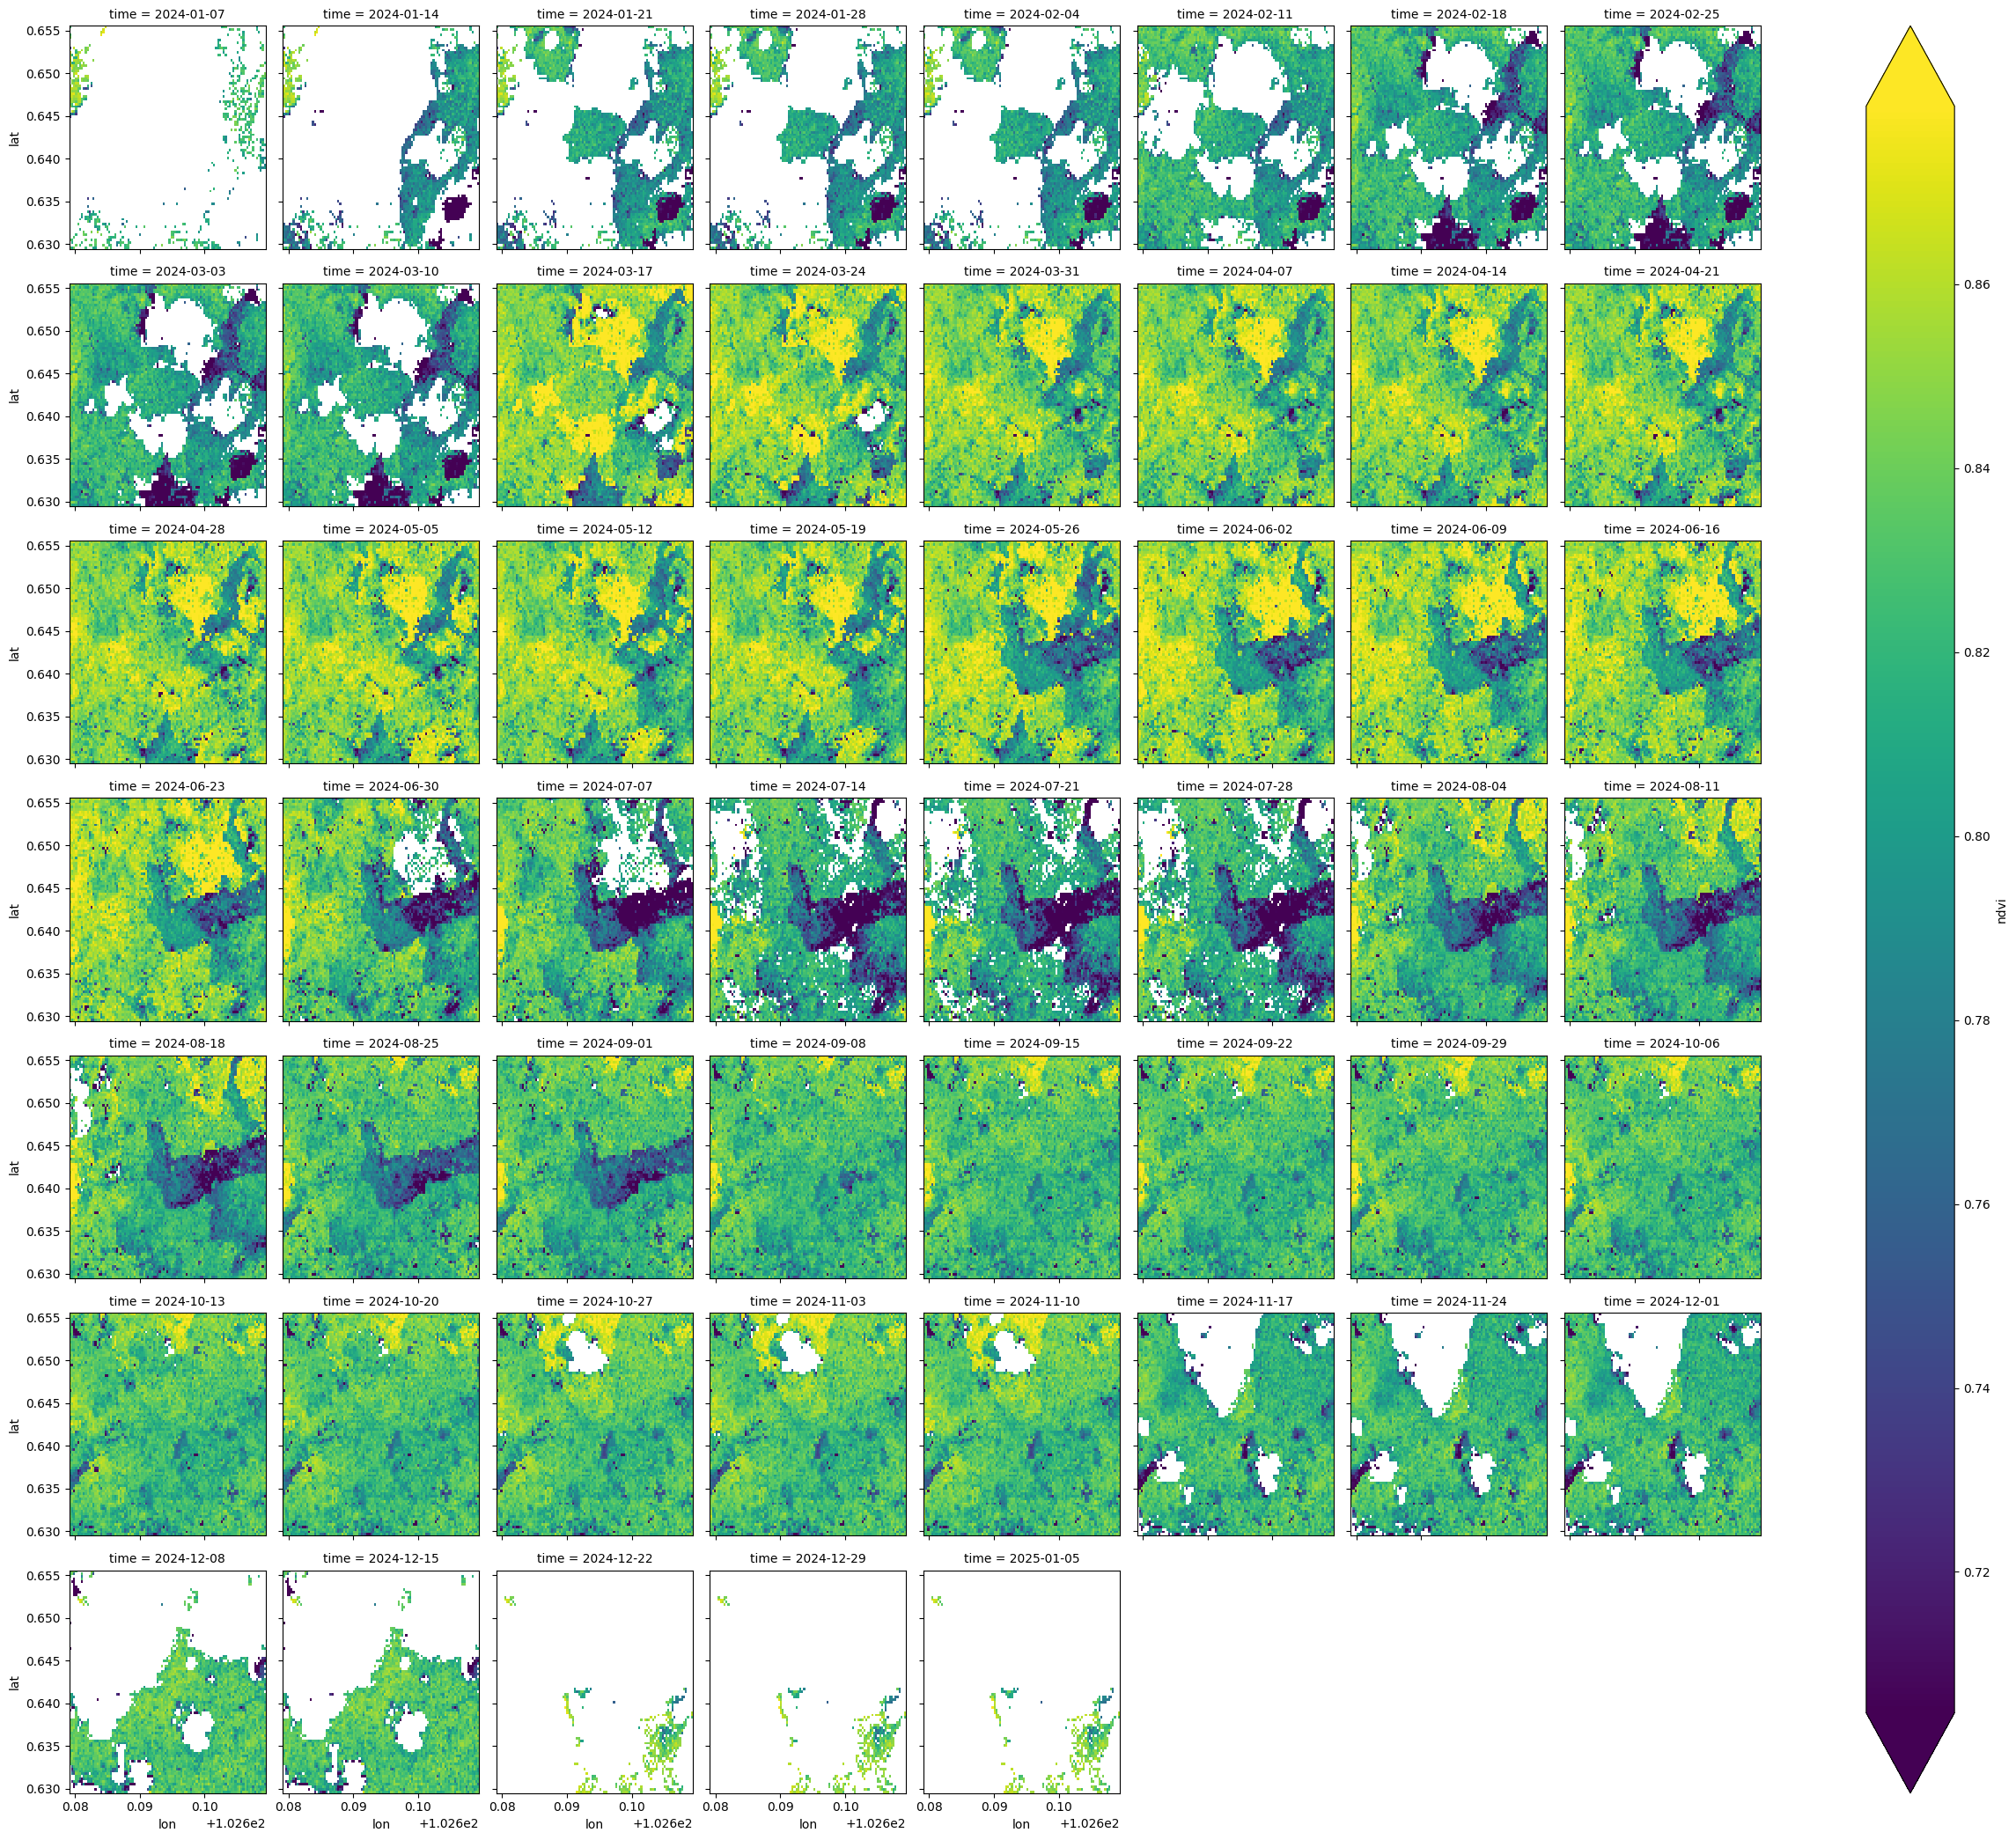

In [20]:
ds_rol.ndvi.plot(
    x = 'lon',
    y = 'lat',
    col = 'time',
    col_wrap = 8,
    robust = True
)

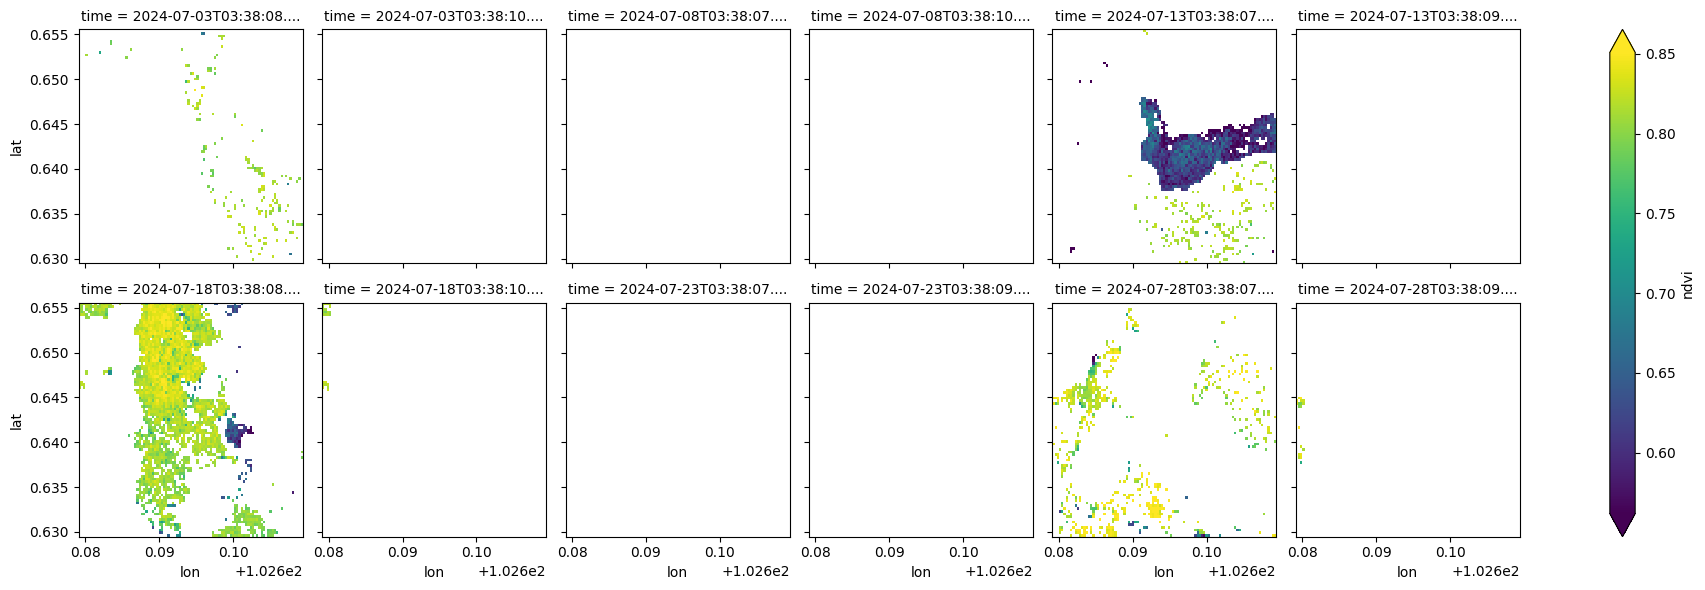

In [21]:
ds.sel(time = ds.time.dt.month == 7).ndvi.plot(
    x = 'lon',
    y = 'lat',
    col = 'time',
    col_wrap = 6,
    robust = True
)